# Tutorial 2: 5-Transistor OTA LVS, PEX, and simulation using gLayout

**By gLayout Team**

**Content creators:** Adrian Sami Pratama, Dharma Anargya Jowandy

___
# Tutorial Objectives

This notebook is a tutorial on-

- **LVS (Layout Versus Schematic):**  
  You will learn how to compare your physical layout with the original schematic to ensure they are functionally identical. This process helps catch connectivity or device mismatches before fabrication.

- **Extraction and Simulation:**  
  The tutorial will guide you through extracting parasitic elements from your layout, such as capacitance and resistance, to create a more accurate circuit model. You will then simulate the extracted netlist to analyze and verify the real-world performance of your design.

### What is a 5T OTA?

A 5-Transistor Operational Transconductance Amplifier (5T OTA) is one of the most fundamental analog circuit building blocks. It converts a differential input voltage into an output current. The circuit consists of:

- **M1, M2** — Differential input pair (NMOS)
- **M3, M4** — Current mirror load (PMOS)
- **M5** — Tail current source (NMOS)

### Schematic Reference

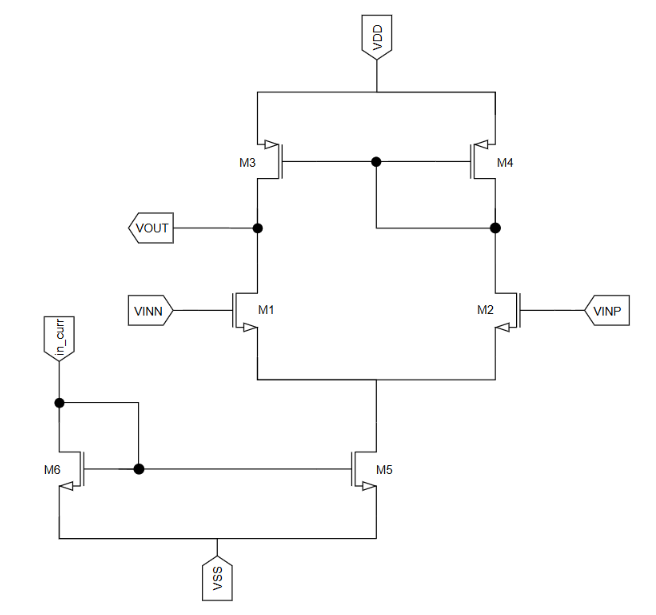

## **NetList generation and LVS**
let's go through the step by step procedure to generate LVS and DRC clean layout of a FVF cell.

In [ ]:
import os
import subprocess

# Run a shell, source .bashrc, then printenv
cmd = 'bash -c "source ~/.bashrc && printenv"'
result = subprocess.run(cmd, shell=True, text=True, capture_output=True)
env_vars = {}
for line in result.stdout.splitlines():
    if '=' in line:
        key, value = line.split('=', 1)
        env_vars[key] = value

# Now, update os.environ with these
os.environ.update(env_vars)

In [ ]:
from glayout import MappedPDK, sky130 , gf180
#from gdsfactory.cell import cell
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle

In [ ]:
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring

In [ ]:
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist

In [ ]:
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route

In [ ]:
fivet_ota_code_string = """
from glayout import MappedPDK, sky130 , gf180
# from gdsfactory.cell import cell
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle

from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring

from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist

from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route


###### Only Required for IIC-OSIC Docker
import os
import subprocess

# Run a shell, source .bashrc, then printenv
cmd = 'bash -c "source ~/.bashrc && printenv"'
result = subprocess.run(cmd, shell=True, text=True, capture_output=True)
env_vars = {}
for line in result.stdout.splitlines():
    if '=' in line:
        key, value = line.split('=', 1)
        env_vars[key] = value

# Now, update os.environ with these
os.environ.update(env_vars)


def add_fivet_ota_labels(
    fivet_ota_in: Component,
    pdk: MappedPDK,
) -> Component:
    fivet_ota_in.unlock()

    psize=(0.5,0.5)
    # list that will contain all port/comp info
    move_info = list()
    # create labels and append to info list

    # vss
    vsslabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
    vsslabel.add_label(text="VSS",layer=pdk.get_glayer("met2_label"))
    move_info.append((vsslabel,fivet_ota_in.ports["VSS_bottom_met_E"],None))
    #vss_ref = top_level << vsslabel;
    
    # vdd
    vddlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
    vddlabel.add_label(text="VDD",layer=pdk.get_glayer("met2_label"))
    move_info.append((vddlabel,fivet_ota_in.ports["VDD_bottom_met_E"],None))
    #vdd_ref = top_level << vddlabel;
    
    # vinp
    vinplabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
    vinplabel.add_label(text="VINP",layer=pdk.get_glayer("met2_label"))
    move_info.append((vinplabel,fivet_ota_in.ports["VINP_bottom_met_E"],None))
    #vinp_ref = top_level << vinplabel;
    
    # vinn
    vinnlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
    vinnlabel.add_label(text="VINN",layer=pdk.get_glayer("met2_label"))
    move_info.append((vinnlabel,fivet_ota_in.ports["VINN_bottom_met_W"],None))
    #vinn_ref = top_level << vinnlabel;
    
    # vout
    voutlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
    voutlabel.add_label(text="VOUT",layer=pdk.get_glayer("met2_label"))
    move_info.append((voutlabel,fivet_ota_in.ports["VOUT_bottom_met_W"],None))
    #out_ref = top_level << outlabel;
    
    # in_cur
    in_curlabel = rectangle(layer=pdk.get_glayer("met2_pin"),size=psize,centered=True).copy()
    in_curlabel.add_label(text="IN_CUR",layer=pdk.get_glayer("met2_label"))
    move_info.append((in_curlabel,fivet_ota_in.ports["INCUR_bottom_met_W"],None))
    #in_cur_ref = top_level << in_curlabel;

    # move everything to position
    for comp, prt, alignment in move_info:
        alignment = ('c','b') if alignment is None else alignment
        compref = align_comp_to_port(comp, prt, alignment=alignment)
        fivet_ota_in.add(compref)
        
    return fivet_ota_in.flatten()

# @cell

def fivet_ota(
    pdk: MappedPDK,
    input_pair: dict = {
        "width": 5.75,
        "length": 0.4,
        "fingers": 2,
        "multipliers": 1,
        "device_type": "nmos",
    },
    current_mirror_cfg: dict = {
        "width": 8.45,
        "length": 0.4,
        "fingers": 5,
        "multipliers": 1,
        "device_type": "pmos",
    },
    tail_source: dict = {
        "width": 9.55,
        "length": 0.7,
        "fingers": 5,
        "multipliers": 1,
        "device_type": "nmos",
    },
    layout_rules: dict = {
        "spacing": 2.0,
        "routing_metal": "met2",
        "dummy_devices": True,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
    **kwargs
) -> Component:

    pdk.activate()

    fivet_ota_config = {
        "input_pair": input_pair,
        "current_mirror": current_mirror_cfg,
        "tail_source": tail_source,
        "layout_rules": layout_rules,
    }

    nmos_kwargs = {
        "with_tie": False,
        "with_dnwell": False,
        "sd_route_topmet": "met2",
        "gate_route_topmet": "met2",
        "sd_route_left": True,
        "rmult": None,
        "gate_rmult": 1,
        "interfinger_rmult": 1,
        "substrate_tap_layers": layout_rules["tie_layers"],
        "dummy_routes": True,
    }

    pmos_kwargs = {
        "with_tie": False,
        "dnwell": False,
        "sd_route_topmet": "met2",
        "gate_route_topmet": "met2",
        "sd_route_left": True,
        "rmult": None,
        "gate_rmult": 1,
        "interfinger_rmult": 1,
        "substrate_tap_layers": layout_rules["tie_layers"],
        "dummy_routes": True,
    }
    
    #top level component
    top_level = Component(name="fivet_ota")

    def current_mirror(pdk, config):
        cm_comp = Component(name="current_mirror")
        
        # ambil parameter dari config
        width       = config["current_mirror"]["width"]
        length      = config["current_mirror"]["length"]
        fingers     = config["current_mirror"]["fingers"]
        multipliers = config["current_mirror"]["multipliers"]
        tie_layers  = config["layout_rules"]["tie_layers"]
        sd_rmult    = config["layout_rules"]["sd_rmult"]
        
        # ============ Instantiate 2 PMOS ============
        pfet_ref = pmos(pdk, width=width, length=length, fingers=fingers,
                        multipliers=multipliers,
                        with_substrate_tap=False,
                        with_dummy=(False, True),
                        tie_layers=tie_layers,
                        sd_rmult=sd_rmult,
                        **pmos_kwargs)
        pfet_mir = pmos(pdk, width=width, length=length, fingers=fingers,
                        multipliers=multipliers,
                        with_substrate_tap=False,
                        with_dummy=(True, False),
                        tie_layers=tie_layers,
                        sd_rmult=sd_rmult,
                        **pmos_kwargs)
        
        cref_ref = cm_comp << pfet_ref
        cmir_ref = cm_comp << pfet_mir
        cref_ref.name = "pfet_ref"
        cmir_ref.name = "pfet_mir"
        
        # ============ Placement ============
        cref_ref.movex(evaluate_bbox(pfet_mir)[0] + pdk.util_max_metal_seperation())
        
        # ============ Tapring ============
        tap_ring = tapring(pdk, 
            enclosed_rectangle=evaluate_bbox(
                cm_comp.flatten(),
                padding=pdk.get_grule("nwell", "active_diff")["min_enclosure"]),
            sdlayer="n+s/d",                        
            horizontal_glayer=tie_layers[0],        
            vertical_glayer=tie_layers[1])          
        shift_amount = -prec_center(cm_comp.flatten())[0]
        tring_ref = cm_comp << tap_ring
        tring_ref.movex(destination=shift_amount)
        
        # Add nwell padding to close gap between nwell
        cm_comp.add_padding(layers=(pdk.get_glayer("nwell"),), default=1)
        
        # ============ Internal routing ============
        cm_comp << straight_route(pdk, cref_ref.ports["multiplier_0_source_E"],
                                       cmir_ref.ports["multiplier_0_source_E"])
        cm_comp << straight_route(pdk, cref_ref.ports["multiplier_0_gate_E"],
                                       cmir_ref.ports["multiplier_0_gate_E"])
        cm_comp << c_route(pdk, cref_ref.ports["multiplier_0_gate_E"],
                                cref_ref.ports["multiplier_0_drain_E"])
        
        # ============ Expose ports ============
        cm_comp.add_ports(cref_ref.get_ports_list(), prefix="REF_")
        cm_comp.add_ports(cmir_ref.get_ports_list(), prefix="MIR_")
        cm_comp.add_ports(tring_ref.get_ports_list(), prefix="TRING_")
        cm_comp.info.update({"pfet_ref": pfet_ref, "pfet_mir": pfet_mir})
        
        return cm_comp
        
    # ============ Add to top level ============
    cm = current_mirror(pdk, fivet_ota_config)
    cm_ref = top_level << cm
    cm_ref.name = "current_mirror"

    def diff_pair(pdk, config):
        dp_comp = Component(name="diff_pair")
        
        # ambil parameter dari config
        width       = config["input_pair"]["width"]
        length      = config["input_pair"]["length"]
        fingers     = config["input_pair"]["fingers"]
        multipliers = config["input_pair"]["multipliers"]
        tie_layers  = config["layout_rules"]["tie_layers"]
        sd_rmult    = config["layout_rules"]["sd_rmult"]
        
        # ============ Instantiate 2 NMOS ============
        m1 = nmos(pdk, width=width, length=length, fingers=fingers,
                  multipliers=multipliers,
                  with_substrate_tap=False,
                  with_dummy=(True , False),
                  tie_layers=tie_layers,
                  sd_rmult=sd_rmult,
                  **nmos_kwargs)
        m2 = nmos(pdk, width=width, length=length, fingers=fingers,
                  multipliers=multipliers,
                  with_substrate_tap=False,
                  with_dummy=(False,True),
                  tie_layers=tie_layers,
                  sd_rmult=sd_rmult,
                  **nmos_kwargs)
        
        m1_ref = dp_comp << m1
        m2_ref = dp_comp << m2
        m1_ref.name = "M1" # M1 is the negative input diffpair
        m2_ref.name = "M2" # M2 is the positive input diffpair
        
        # ============ Placement ============
        ref_dimensions = evaluate_bbox(m1)
        m2_ref.movex(m1_ref.xmax)
        m2_ref.movex(ref_dimensions[0]/2)
        m2_ref.movex(pdk.util_max_metal_seperation())
        
        # ============ Internal routing ============
        dp_comp << straight_route(pdk,
            m1_ref.ports["multiplier_0_source_E"],
            m2_ref.ports["multiplier_0_source_W"])
        
        # ============ Tapring ============
        tap_ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(
            dp_comp.flatten(),
            padding=pdk.get_grule("nwell", "active_diff")["min_enclosure"]))
        shift_amount = -prec_center(dp_comp.flatten())[0]
        tring_ref = dp_comp << tap_ring
        tring_ref.movex(destination=shift_amount)
        
        # ============ Expose ports ============
        dp_comp.add_ports(m1_ref.get_ports_list(), prefix="M1_")
        dp_comp.add_ports(m2_ref.get_ports_list(), prefix="M2_")
        dp_comp.add_ports(tring_ref.get_ports_list(), prefix="TRING_")
        dp_comp.info.update({"M1": m1, "M2": m2})
        
        return dp_comp
        
    # ============ Test ============
    dp = diff_pair(pdk, fivet_ota_config)
    dp_ref = top_level << dp
    dp_ref.name = "diff_pair"
    
    def tail_current(pdk, config):
        tail_comp = Component(name="tail_current")
        
        # ambil parameter dari config
        width       = config["tail_source"]["width"]
        length      = config["tail_source"]["length"]
        fingers     = config["tail_source"]["fingers"]
        multipliers = config["tail_source"]["multipliers"]
        tie_layers  = config["layout_rules"]["tie_layers"]
        sd_rmult    = config["layout_rules"]["sd_rmult"]
        
        # ============ Instantiate 2 NMOS ============
        nfet_ref = nmos(pdk, width=width, length=length, fingers=fingers,
                        multipliers=multipliers,
                        with_substrate_tap=False,
                        with_dummy=(False, True),
                        tie_layers=tie_layers,
                        sd_rmult=sd_rmult,
                        **nmos_kwargs)
        nfet_mir = nmos(pdk, width=width, length=length, fingers=fingers,
                        multipliers=multipliers,
                        with_substrate_tap=False,
                        with_dummy=(True, False),
                        tie_layers=tie_layers,
                        sd_rmult=sd_rmult,
                        **nmos_kwargs)
        
        tref_ref = tail_comp << nfet_ref
        tmir_ref = tail_comp << nfet_mir
        tref_ref.name = "nfet_ref"
        tmir_ref.name = "nfet_mir"
        
        # ============ Placement ============
        tref_ref.movex(evaluate_bbox(nfet_mir)[0] + pdk.util_max_metal_seperation())
        
        # ============ Tapring ============
        tap_ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(
            tail_comp.flatten(),
            padding=pdk.get_grule("nwell", "active_diff")["min_enclosure"]))
        shift_amount = -prec_center(tail_comp.flatten())[0]
        tring_ref = tail_comp << tap_ring
        tring_ref.movex(destination=shift_amount)
        
        # ============ Internal routing ============
        tail_comp << straight_route(pdk, tref_ref.ports["multiplier_0_source_E"],
                                         tmir_ref.ports["multiplier_0_source_E"])
        tail_comp << straight_route(pdk, tref_ref.ports["multiplier_0_gate_E"],
                                         tmir_ref.ports["multiplier_0_gate_E"])
        tail_comp << c_route(pdk, tref_ref.ports["multiplier_0_gate_E"],
                                  tref_ref.ports["multiplier_0_drain_E"])
        
        # ============ Expose ports ============
        tail_comp.add_ports(tref_ref.get_ports_list(), prefix="REF_")
        tail_comp.add_ports(tmir_ref.get_ports_list(), prefix="MIR_")
        tail_comp.add_ports(tring_ref.get_ports_list(), prefix="TRING_")
        tail_comp.info.update({"nfet_ref": nfet_ref, "nfet_mir": nfet_mir})
        
        return tail_comp
        
    # ============ Test ============
    tail = tail_current(pdk, fivet_ota_config)
    tail_ref = top_level << tail
    tail_ref.name = "tail_current"
    
    # Hitung bbox masing-masing di top-level
    dp_dimensions   = evaluate_bbox(dp)
    tail_dimensions = evaluate_bbox(tail)
    
    # diff_pair → letakkan di bawah current_mirror
    dp_ref.movey(cm_ref.ymin - dp_dimensions[1]/2 - pdk.util_max_metal_seperation())
    
    # tail_current → letakkan di bawah diff_pair
    tail_ref.movey(dp_ref.ymin - tail_dimensions[1]/2 - pdk.util_max_metal_seperation())
    
    # Pakai center absolut langsung
    dp_ref.movex(cm_ref.center[0] - dp_ref.center[0])
    tail_ref.movex(cm_ref.center[0] - tail_ref.center[0])

    viam2m3 = via_stack(pdk, "met2", "met3", centered=True)
    viam1m2 = via_stack(pdk, "met1", "met2", centered=True)
    
    # Via drain kiri current mirror
    drain_mir_via = top_level << viam2m3
    drain_mir_via.move(cm_ref.ports["MIR_multiplier_0_drain_W"].center).movex(-5)
    
    # Via drain kanan current mirror
    drain_ref_via = top_level << viam2m3
    drain_ref_via.move(cm_ref.ports["REF_multiplier_0_drain_E"].center).movex(5)
    
    # Via drain kiri diffpair
    drain_m1_via = top_level << viam2m3
    drain_m1_via.move(dp_ref.ports["M1_multiplier_0_drain_W"].center).movex(-5)
    drain_m1_via.movex(drain_mir_via.x - drain_m1_via.x)
    
    # Via drain kanan diffpair
    drain_m2_via = top_level << viam2m3
    drain_m2_via.move(dp_ref.ports["M2_multiplier_0_drain_E"].center).movex(5)
    drain_m2_via.movex(drain_ref_via.x - drain_m2_via.x)
    
    # Via source diffpair
    source_m1_via = top_level << viam2m3
    source_m1_via.move(dp_ref.ports["M1_multiplier_0_source_W"].center)
    
    # Via drain current tail
    drain_sink_via = top_level << viam2m3
    drain_sink_via.move(tail_ref.ports["MIR_multiplier_0_drain_W"].center)
    source_m1_via.movex(drain_sink_via.x - source_m1_via.x)

    # 1. CM kanan (drain_mir_via) → drain M1 diff pair
    top_level << straight_route(pdk,
        drain_mir_via.ports["top_met_N"],
        drain_m1_via.ports["top_met_S"])
    
    # 2. CM kiri (drain_ref_via) → drain M2 diff pair
    top_level << straight_route(pdk,
        drain_ref_via.ports["top_met_N"],
        drain_m2_via.ports["top_met_S"])
    
    # 3. Source common diff pair → drain tail
    top_level << straight_route(pdk,
        source_m1_via.ports["top_met_N"],
        drain_sink_via.ports["top_met_S"])

    # MIR drain → drain_ref_via
    top_level << straight_route(pdk,
        cm_ref.ports["MIR_multiplier_0_drain_E"],
        drain_mir_via.ports["bottom_met_W"])
    
    # REF drain → drain_mir_via
    top_level << straight_route(pdk,
        cm_ref.ports["REF_multiplier_0_drain_W"],
        drain_ref_via.ports["bottom_met_E"])
    
    # M1 drain → drain_l_pair_via
    top_level << straight_route(pdk,
        dp_ref.ports["M1_multiplier_0_drain_E"],
        drain_m1_via.ports["bottom_met_W"])
    
    # M2 drain → drain_r_pair_via
    top_level << straight_route(pdk,
        dp_ref.ports["M2_multiplier_0_drain_W"],
        drain_m2_via.ports["bottom_met_E"])
    
    top_level << straight_route(pdk,
        dp_ref.ports["M2_multiplier_0_source_E"],
        drain_sink_via.ports["bottom_met_W"])
    
    # Route VDD to N+ tapring
    top_level << straight_route(pdk,
        cm_ref.ports["MIR_multiplier_0_source_E"],
        cm_ref.ports["TRING_W_top_met_W"])
    
    # Route VSS to P+ tapring
    top_level << straight_route(pdk,
        tail_ref.ports["REF_multiplier_0_source_E"],
        tail_ref.ports["TRING_W_top_met_W"])
    
    # Route tail tapring to diffpair tapring
    top_level << straight_route(pdk,
        dp_ref.ports["TRING_S_top_met_N"],
        tail_ref.ports["TRING_N_top_met_S"])

    # Expose signal ports 
    top_level.add_port(name="VSS_bottom_met_E",   port=tail_ref.ports["REF_multiplier_0_source_E"])
    top_level.add_port(name="VDD_bottom_met_E",   port=cm_ref.ports["MIR_multiplier_0_source_E"])
    top_level.add_port(name="VINP_bottom_met_E",  port=dp_ref.ports["M2_multiplier_0_gate_E"])
    top_level.add_port(name="VINN_bottom_met_W",  port=dp_ref.ports["M1_multiplier_0_gate_W"])
    top_level.add_port(name="VOUT_bottom_met_W",  port=drain_mir_via.ports["top_met_W"])
    top_level.add_port(name="INCUR_bottom_met_W", port=tail_ref.ports["MIR_multiplier_0_gate_W"])

    top_level.info.update({
        "m1":       dp.info["M1"],
        "m2":       dp.info["M2"],
        "pfet_ref": cm.info["pfet_ref"],
        "pfet_mir": cm.info["pfet_mir"],
        "nfet_tail_ref": tail.info["nfet_ref"],
        "nfet_tail_mir": tail.info["nfet_mir"],
    })
    return component_snap_to_grid(rename_ports_by_orientation(top_level))

if __name__ == "__main__":
    comp = fivet_ota(gf180)
    comp = add_fivet_ota_labels(comp, gf180)
    comp.name = "FIVET_OTA"
    comp.write_gds('out_fivet_ota.gds')
    comp.show()
    print("...Running DRC...")
    drc_result = gf180.drc_magic(comp, "FIVET_OTA")

"""

fivet_ota_init_string = """
### Glayout 5T OTA Cell.

from .my_fivet_ota import fivet_ota, add_fivet_ota_labels

__all__ = [
    'fivet_ota',
    'add_fivet_ota_labels',
]
"""

directory = "../../FIVET_OTA/"
os.makedirs(directory, exist_ok=True)

# Save to a .py file
with open(directory + "my_fivet_ota.py", "w") as file:
    file.write(fivet_ota_code_string)

with open(directory + "__init__.py", "w") as file:
    file.write(fivet_ota_init_string)

In [ ]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.abspath("../../FIVET_OTA"))
from my_fivet_ota import fivet_ota, add_fivet_ota_labels

In [ ]:
def fivet_ota_netlist(ota_in: Component) -> Component:
    m1        = ota_in.info["m1"]
    m2        = ota_in.info["m2"]
    pfet_ref  = ota_in.info["pfet_ref"]
    pfet_mir  = ota_in.info["pfet_mir"]
    nfet_tail_ref = ota_in.info["nfet_tail_ref"]
    nfet_tail_mir = ota_in.info["nfet_tail_mir"]

    netlist = Netlist(
        circuit_name='FIVET_OTA',
        nodes=['VINP', 'VINN', 'VOUT', 'VDD', 'VSS', 'IN_CUR']
    )

    netlist.connect_netlist(m1.info['netlist'],        [('D', 'VOUT'),  ('G', 'VINP'),   ('S', 'VTAIL'), ('B', 'VSS')])
    netlist.connect_netlist(m2.info['netlist'],        [('D', 'VMID'),  ('G', 'VINN'),   ('S', 'VTAIL'), ('B', 'VSS')])
    netlist.connect_netlist(pfet_ref.info['netlist'],  [('D', 'VMID'),  ('G', 'VMID'),   ('S', 'VDD'),   ('B', 'VDD')])
    netlist.connect_netlist(pfet_mir.info['netlist'],  [('D', 'VOUT'),  ('G', 'VMID'),   ('S', 'VDD'),   ('B', 'VDD')])
    netlist.connect_netlist(nfet_tail_ref.info['netlist'], [('D','VTAIL'), ('G','IN_CUR'), ('S','VSS'), ('B','VSS')])
    netlist.connect_netlist(nfet_tail_mir.info['netlist'], [('D','VTAIL'), ('G','IN_CUR'), ('S','VSS'), ('B','VSS')])

    ota_in.info['netlist'] = netlist
    return ota_in

my_ota = fivet_ota_netlist(fivet_ota(gf180))
my_ota = add_fivet_ota_labels(my_ota, gf180)
my_ota.name = "FIVET_OTA"
my_ota.show()
print(my_ota.info['netlist'].generate_netlist())

In [ ]:
comp = fivet_ota(gf180)
print_ports(comp)

In [ ]:
my_ota = fivet_ota_netlist(add_fivet_ota_labels(fivet_ota(gf180), gf180))
my_ota.name = "fivet_OTA"
ota_gds = my_ota.write_gds("fivet_ota.gds")
my_ota.show()
netgen_lvs_result = gf180.lvs_netgen(my_ota, my_ota.name)